# Song Classification
Exploratory data analysis on a Spotify tracks dataset. Evaluating regressor performance and determining the best attributes to use for song popularity prediction.

In [205]:
# imports
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor

import plot_utils

## Data Preparation
### A Look at the Dataset
Data source: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset    
TODO description of attributes  

### Data Cleaning
Dropped the track id and track name as these are not useful in predictive tasks.

0          0.000000
1          0.143100
2          0.223100
3          0.263333
4          0.290883
            ...    
113995    76.064950
113996    78.838367
113997    79.817100
113998    79.817100
113999    87.288250
Length: 114000, dtype: float64
num of songs greater than or equal to 20 mins long 301


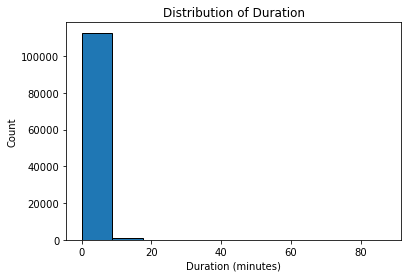

In [206]:
songs = pd.read_csv("input_data/dataset.csv")

drop_columns = ["Unnamed: 0", "track_id", "track_name"]
for col in drop_columns:
    songs.pop(col)

# prep data for display in histograms
duration_ms = songs["duration_ms"]
danceability = songs["danceability"]
loudness = songs["loudness"]
instrumentalness = songs["instrumentalness"]

duration_minutes = [(ms / 1000) / 60 for ms in duration_ms]
print(pd.Series(sorted(duration_minutes)))
count = 0
for time in duration_minutes:
    if time >= 12:
        count = count + 1
print("num of songs greater than or equal to 12 mins long", count)

# TODO drop all songs 12 mins or longer to clean up histogram
plot_utils.make_histogram(duration_minutes, "Distribution of Duration", "Duration (minutes)", "Count")

# TODO generate histograms

# TODO check how many keys are value of -1 (means no key is detected to see if we can use this attribute for prediction or not
# TODO decide what to do with those entries with a key of -1, do we drop them if we are using key?
# TODO perform EDA tasks (check if data distribution is normal, etc.)
# TODO normalization is not necessary bc numerical values are already probabilities in a range from 0 to 1
# TODO curious to find out which albums by certain artists are their most popular?
# TODO determine best attributes to predict on (by trying all possible combos or using association rule miner)

# TODO using a linear regressor, SGD (stochastic gradient descent regressor), knn regressor and decision tree regressor

In [207]:
key = songs["key"]

### Exploratory Data Analysis
TODO use plot utils to generate some diagrams, guess at the best attributes for prediction

## Train/Test Set Building
Using stratified k-fold cross validation (with k=10).

In [208]:
y = np.array(songs.pop("popularity"))
X = np.array(songs)

## Regressor Initialization
Comparing the performance of the KNN regressor, SGD regressor, and decision tree regressor, with a linear regressor as a baseline.

## Regressor Evaluation
Using the following metrics:
* Accuracy and error rate
* Precision, recall, and F1 measure